<a href="https://colab.research.google.com/github/suuu004/RL/blob/main/RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 사전 세팅

In [1]:
# 1. 필수 라이브러리 설치 (코랩 첫 번째 셀에서 실행)
!pip install -q gymnasium torch

In [2]:
# 2. DQN 코드 실행 테스트 (두 번째 셀)
import gymnasium as gym
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

# Q-Network
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.fc(x)

# 코랩 GPU/CPU 자동 감지
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 중인 디바이스: {device}")

# gymnasium 환경 생성 (render_mode 없이 설정하여 그래픽 에러 방지)
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

q_net = QNetwork(state_dim, action_dim).to(device)
optimizer = optim.Adam(q_net.parameters(), lr=0.001)
memory = deque(maxlen=2000)

state, _ = env.reset()
done = False

# 1 에피소드 데이터 수집
while not done:
    if random.random() < 0.1:
        action = env.action_space.sample()
    else:
        state_t = torch.FloatTensor(state).to(device)
        action = torch.argmax(q_net(state_t)).item()

    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    memory.append((state, action, reward, next_state, done))
    state = next_state

print("데이터 수집 완료! 메모리 크기:", len(memory))

사용 중인 디바이스: cpu
데이터 수집 완료! 메모리 크기: 26


## PPO


In [4]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

# Actor-Critic 신경망
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        # Actor: 각 행동의 확률 분포 출력
        self.actor = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
            nn.Softmax(dim=-1)
        )
        # Critic: 상태 가치 V(s) 출력
        self.critic = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.actor(x), self.critic(x)

# PPO 학습 및 테스트
env = gym.make("CartPole-v1")
model = ActorCritic(env.observation_space.shape[0], env.action_space.n)
optimizer = optim.Adam(model.parameters(), lr=0.002)

clip_eps = 0.2  # PPO 핵심 하이퍼파라미터 (Clipping 범위)
gamma = 0.99

# 1 에피소드 데이터 수집 (On-Policy)
states, actions, log_probs, rewards, dones = [], [], [], [], []
state, _ = env.reset()
done = False

while not done:
    state_t = torch.FloatTensor(state)
    probs, _ = model(state_t)
    dist = Categorical(probs)
    action = dist.sample()

    next_state, reward, terminated, truncated, _ = env.step(action.item())
    done = terminated or truncated

    states.append(state)
    actions.append(action.item())
    log_probs.append(dist.log_prob(action).detach())
    rewards.append(reward)
    dones.append(done)
    state = next_state

# PPO 업데이트 Step (Clipped Loss)
s_t = torch.FloatTensor(states)
a_t = torch.LongTensor(actions)
old_log_probs_t = torch.stack(log_probs)

# Discounted Returns 및 Advantage(A) 계산
returns = []
discounted_sum = 0
for r, d in zip(reversed(rewards), reversed(dones)):
    if d: discounted_sum = 0
    discounted_sum = r + gamma * discounted_sum
    returns.insert(0, discounted_sum)

returns_t = torch.FloatTensor(returns).unsqueeze(1)
probs, values = model(s_t)
advantage = (returns_t - values.detach()).squeeze()

# PPO Clipped Objective 계산
dist = Categorical(probs)
new_log_probs = dist.log_prob(a_t)

ratio = torch.exp(new_log_probs - old_log_probs_t)  # pi_new / pi_old
surr1 = ratio * advantage
surr2 = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * advantage

# Actor Loss + Critic Loss
actor_loss = -torch.min(surr1, surr2).mean()
critic_loss = nn.MSELoss()(values, returns_t)
total_loss = actor_loss + 0.5 * critic_loss

optimizer.zero_grad()
total_loss.backward()
optimizer.step()
print(f"[PPO] Loss: {total_loss.item():.4f}")

[PPO] Loss: 38.0666


/tmp/ipykernel_2026/380249920.py:58: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  s_t = torch.FloatTensor(states)


##Q-learning


In [5]:
import gymnasium as gym
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

# Q-Network 정의
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.fc(x)

# DQN 학습 및 테스트
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

q_net = QNetwork(state_dim, action_dim)
optimizer = optim.Adam(q_net.parameters(), lr=0.001)
memory = deque(maxlen=2000)

gamma = 0.99
epsilon = 0.1  # 탐험(Exploration) 확률

# 경험 수집 (1 에피소드)
state, _ = env.reset()
done = False
while not done:
    if random.random() < epsilon:
        action = env.action_space.sample()  # 무작위 행동
    else:
        state_t = torch.FloatTensor(state)
        action = torch.argmax(q_net(state_t)).item()  # max Q(s, a) 행동 선택

    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    memory.append((state, action, reward, next_state, done))
    state = next_state

# Q-learning (DQN) 업데이트 step
if len(memory) >= 32:
    batch = random.sample(memory, 32)
    s, a, r, ns, d = zip(*batch)

    s_t = torch.FloatTensor(s)
    a_t = torch.LongTensor(a).unsqueeze(1)
    r_t = torch.FloatTensor(r).unsqueeze(1)
    ns_t = torch.FloatTensor(ns)
    d_t = torch.FloatTensor(d).unsqueeze(1)

    # Q(s, a) 계산
    q_values = q_net(s_t).gather(1, a_t)

    # TD Target = r + gamma * max Q(s', a')
    with torch.no_grad():
        max_next_q = q_net(ns_t).max(1, keepdim=True)[0]
        target = r_t + gamma * max_next_q * (1 - d_t)

    # MSE Loss 및 역전파
    loss = nn.MSELoss()(q_values, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"[DQN] Loss: {loss.item():.4f}")

###Q-learning vs. PPO

사용 중인 디바이스: cpu
--- DQN 학습 시작 ---
[DQN] Episode 50/300 | Reward: 73.0
[DQN] Episode 100/300 | Reward: 50.0
[DQN] Episode 150/300 | Reward: 87.0
[DQN] Episode 200/300 | Reward: 12.0
[DQN] Episode 250/300 | Reward: 101.0
[DQN] Episode 300/300 | Reward: 163.0

--- PPO 학습 시작 ---
[PPO] Episode 50/300 | Reward: 55.0
[PPO] Episode 100/300 | Reward: 30.0
[PPO] Episode 150/300 | Reward: 22.0
[PPO] Episode 200/300 | Reward: 33.0
[PPO] Episode 250/300 | Reward: 345.0
[PPO] Episode 300/300 | Reward: 277.0


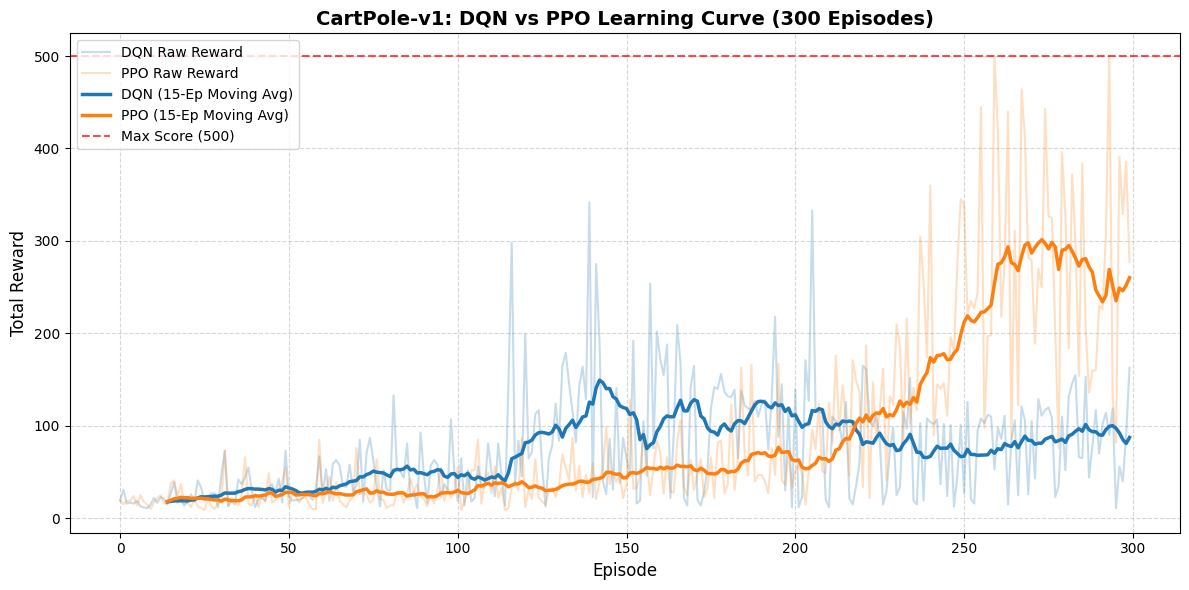

In [6]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# 디바이스 설정 (GPU 사용 가능 시 GPU 활용)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 중인 디바이스: {device}")

# Seed 고정 (공정한 비교를 위해)
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

# ==========================================
# 1. DQN 구현
# ==========================================
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.fc(x)

def train_dqn(env_name, episodes=300):
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    q_net = QNetwork(state_dim, action_dim).to(device)
    target_net = QNetwork(state_dim, action_dim).to(device)
    target_net.load_state_dict(q_net.state_dict())

    optimizer = optim.Adam(q_net.parameters(), lr=0.001)
    memory = deque(maxlen=10000)

    epsilon = 1.0
    epsilon_min = 0.01
    epsilon_decay = 0.995
    gamma = 0.99
    batch_size = 64

    dqn_rewards = []

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            # Epsilon-Greedy 행동 선택
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                with torch.no_grad():
                    action = torch.argmax(q_net(state_t)).item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            memory.append((state, action, reward, next_state, done))
            state = next_state
            total_reward += reward

            # Mini-batch 학습
            if len(memory) >= batch_size:
                batch = random.sample(memory, batch_size)
                s_b, a_b, r_b, ns_b, d_b = zip(*batch)

                s_t = torch.FloatTensor(np.array(s_b)).to(device)
                a_t = torch.LongTensor(a_b).unsqueeze(1).to(device)
                r_t = torch.FloatTensor(r_b).unsqueeze(1).to(device)
                ns_t = torch.FloatTensor(np.array(ns_b)).to(device)
                d_t = torch.FloatTensor(d_b).unsqueeze(1).to(device)

                q_values = q_net(s_t).gather(1, a_t)
                with torch.no_grad():
                    max_next_q = target_net(ns_t).max(1, keepdim=True)[0]
                    target = r_t + gamma * max_next_q * (1 - d_t)

                loss = nn.MSELoss()(q_values, target)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        # Target Network 주기적 업데이트 (매 10 에피소드)
        if (ep + 1) % 10 == 0:
            target_net.load_state_dict(q_net.state_dict())

        dqn_rewards.append(total_reward)
        if (ep + 1) % 50 == 0:
            print(f"[DQN] Episode {ep + 1}/{episodes} | Reward: {total_reward}")

    env.close()
    return dqn_rewards

# ==========================================
# 2. PPO 구현
# ==========================================
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.actor = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
            nn.Softmax(dim=-1)
        )
        self.critic = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.actor(x), self.critic(x)

def train_ppo(env_name, episodes=300):
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    model = ActorCritic(state_dim, action_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.002)

    gamma = 0.99
    clip_eps = 0.2
    ppo_rewards = []

    for ep in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0
        states, actions, log_probs, rewards, dones = [], [], [], [], []

        while not done:
            state_t = torch.FloatTensor(state).to(device)
            probs, _ = model(state_t)
            dist = Categorical(probs)
            action = dist.sample()

            next_state, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated

            states.append(state)
            actions.append(action.item())
            log_probs.append(dist.log_prob(action).detach())
            rewards.append(reward)
            dones.append(done)

            state = next_state
            total_reward += reward

        # PPO Update Step
        s_t = torch.FloatTensor(np.array(states)).to(device)
        a_t = torch.LongTensor(actions).to(device)
        old_log_probs_t = torch.stack(log_probs).to(device)

        returns = []
        discounted_sum = 0
        for r, d in zip(reversed(rewards), reversed(dones)):
            if d: discounted_sum = 0
            discounted_sum = r + gamma * discounted_sum
            returns.insert(0, discounted_sum)

        returns_t = torch.FloatTensor(returns).unsqueeze(1).to(device)
        probs, values = model(s_t)
        advantage = (returns_t - values.detach()).squeeze()

        dist = Categorical(probs)
        new_log_probs = dist.log_prob(a_t)
        ratio = torch.exp(new_log_probs - old_log_probs_t)

        surr1 = ratio * advantage
        surr2 = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * advantage

        actor_loss = -torch.min(surr1, surr2).mean()
        critic_loss = nn.MSELoss()(values, returns_t)
        total_loss = actor_loss + 0.5 * critic_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        ppo_rewards.append(total_reward)
        if (ep + 1) % 50 == 0:
            print(f"[PPO] Episode {ep + 1}/{episodes} | Reward: {total_reward}")

    env.close()
    return ppo_rewards

# ==========================================
# 3. 두 모델 학습 및 결과 비교 시각화
# ==========================================
ENV_NAME = "CartPole-v1"
EPISODES = 300

print("--- DQN 학습 시작 ---")
set_seed(42)
dqn_scores = train_dqn(ENV_NAME, episodes=EPISODES)

print("\n--- PPO 학습 시작 ---")
set_seed(42)
ppo_scores = train_ppo(ENV_NAME, episodes=EPISODES)

# 이동 평균 계산 함수 (변동 폭을 부드럽게 시각화)
def moving_average(data, window_size=15):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# 그래프 그리기
plt.figure(figsize=(12, 6))

# 원본 에피소드 보상 (연하게 표시)
plt.plot(dqn_scores, color='#1f77b4', alpha=0.25, label='DQN Raw Reward')
plt.plot(ppo_scores, color='#ff7f0e', alpha=0.25, label='PPO Raw Reward')

# 이동 평균선 (진하게 표시)
window = 15
plt.plot(range(window - 1, EPISODES), moving_average(dqn_scores, window), color='#1f77b4', linewidth=2.5, label='DQN (15-Ep Moving Avg)')
plt.plot(range(window - 1, EPISODES), moving_average(ppo_scores, window), color='#ff7f0e', linewidth=2.5, label='PPO (15-Ep Moving Avg)')

plt.axhline(y=500, color='r', linestyle='--', alpha=0.7, label='Max Score (500)')

plt.title("CartPole-v1: DQN vs PPO Learning Curve (300 Episodes)", fontsize=14, fontweight='bold')
plt.xlabel("Episode", fontsize=12)
plt.ylabel("Total Reward", fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 결과 분석

###1. 학습 속도 및 최종 성능 비교
**초반 구간(0~200)**
- DQN: 100~150 부근에서 이동 평균 보상이 약 150점 수준까지 먼저 상승하며 PPO보다 빠른 적응을 보임
- PPO: 200부근까지는 보상 50~100점 미만 영역에서 완만한 Exploration을 하며 유의미한 상승세를 보이지 못함

**후반 구간 및 수렴 속도(200~300)**
- DQN: 150 이후 오히려 성능이 완만하게 하락 및 정체하면서 100점 미만 구간에 머무름
- PPO:200부근을 넘어가면서 보상이 급격하게 수직 상승해 최고 300점 부근까지 가파르게 수렴함. 250 이후 순간 최고 점수는 만점인 500점 근처까지 도달하기도 함

## 2. 원인 분석
1. DQN의 초반 우세 & 후반 정체 원인
- 초반: Replay Buffer를 통해 과거의 데이터를 반복 재사용(Off-policy)하므로 샘플 효율성이 높아 초기 빠른 보상 획득에 유리했음
- 후반 정체: 단순 DQN 방식은 하이퍼파라미터 튜닝에 매우 민감함. 탐험 확률이 빠르게 줄어들면 국소 최적해에 갇히거나 학습 불균형이 발생하기 쉬움

2. PPO의 초반 탐험 & 후발 폭팔 원인
- 초반: 현재 정책으로 수집한 데이터만 사용하고 버리는 On-policy 방식이므로, 초기 정책 신경망이 정립되기 전까지는 많은 샘플 수집 및 탐험 시간이 필요함
- 후반 폭발: 정책 분포를 직접 업데이트하는 Actor-Critic 구조와 Clipping 기능 덕분에 최적 정책을 찾는 순간 매우 안정적이면서 빠르게 최고 성능으로 수렴함
